In [1]:
! pip install langchain langgraph langchain-nvidia-ai-endpoints langchain-tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 5.6 MB/s eta 0:00:00


In [37]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = ""
os.environ["LANGSMITH_PROJECT"] = ""
os.environ["TAVILY_API_KEY"]=""
os.environ["NVIDIA_API_KEY"]=""

In [3]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA( model="openai/gpt-oss-20b" , temperature=0,
    )

In [7]:
risk_analyst_template = """
You are a senior Risk Analyst with access to the TavilySearch tool.

Analyze the following decision exclusively from a RISK perspective.

Decision:
{decision}

You MAY use TavilySearch to investigate:
- Current market conditions
- Recent industry trends
- Real-world failure cases
- Current regulations or policy changes
- Recent technological risks
- Relevant statistics or factual evidence

Use TavilySearch ONLY when external or up-to-date information would improve the risk analysis.
Do not search for general reasoning that you can perform yourself.

Identify:
- Short-term risks
- Long-term risks
- Hidden risks
- Probability of failure
- Worst realistic outcome

Base factual claims on search results when applicable.

Do NOT analyze ROI or opportunity cost.

Be critical, evidence-driven, precise, and concise.

Return:
Risk Analysis:
Overall Risk Level: LOW | MEDIUM | HIGH
Probability of Failure: 0-100%
Top Risk:
Evidence:
"""

In [4]:
from langchain_tavily import TavilySearch


tool = TavilySearch(
    max_results=5,
    topic="general",
)


In [8]:
from langchain.agents import create_agent

risk_analysis_agent = create_agent(llm , system_prompt=risk_analyst_template , tools=[tool])

In [44]:
class State(TypedDict):
    decision: str

    risk_analysis: str
    roi_analysis: str
    opportunity_cost: str

    aggregated_analysis: str

    verdict: str
    confidence: float
    reasoning: str

    devils_advocate: str


In [45]:
def risk_analysis_node(state: State):
    result = risk_analysis_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": risk_analyst_template.format(
                    decision=state["decision"]
                )
            }
        ]
    })

    risk_analysis = result["messages"][-1].content

    return {
        "risk_analysis": risk_analysis
    }

In [46]:
roi_analyst_template = """
You are a senior ROI Analyst.

Analyze the following decision exclusively from a RETURN ON INVESTMENT perspective.

Decision:
{decision}

Evaluate:
- Required time
- Required effort
- Required resources
- Short-term return
- Long-term return
- Value gained relative to investment

Do NOT analyze risks or opportunity cost.

Be objective and quantitative when possible.

Return:
ROI Analysis:
ROI Score: 0-100
Expected Return:
Investment Required:
"""

In [47]:
from langchain_core.prompts.chat import ChatPromptTemplate
roi_prompt = ChatPromptTemplate.from_template(
    roi_analyst_template
)

roi_analysis_chain = roi_prompt | llm

In [48]:
def roi_analysis_node(state: State):
    result = roi_analysis_chain.invoke({
        "decision": state["decision"]
    })

    return {
        "roi_analysis": result.content
    }

In [49]:
opportunity_cost_template = """
You are a strategic Opportunity Cost Analyst.

Analyze the following decision exclusively from an OPPORTUNITY COST perspective.

Decision:
{decision}

Determine:
- What is sacrificed by choosing this decision
- Alternative paths available
- Better potential uses of time and resources
- Cost of delaying alternatives
- Strongest alternative

Do NOT analyze direct risks or ROI.

Be strategic, critical, and concise.

Return:
Opportunity Cost Analysis:
Opportunity Cost Level: LOW | MEDIUM | HIGH
Best Alternative:
Main Sacrifice:
"""

In [50]:
opportunity_cost_prompt = ChatPromptTemplate.from_template(
    opportunity_cost_template
)

opportunity_cost_chain = opportunity_cost_prompt | llm

In [51]:
def opportunity_cost_analysis_node(state: State):
    result = opportunity_cost_chain.invoke({
        "decision": state["decision"]
    })

    return {
        "opportunity_cost": result.content
    }

In [52]:
def aggregator_node(state: State):
    combined_analysis = f"""
RISK ANALYSIS:
{state["risk_analysis"]}

ROI ANALYSIS:
{state["roi_analysis"]}

OPPORTUNITY COST ANALYSIS:
{state["opportunity_cost"]}
"""

    return {
        "aggregated_analysis": combined_analysis
    }

In [53]:
from typing import Literal
from pydantic import BaseModel, Field


In [54]:
class JudgeOutput(BaseModel):
    verdict: Literal["ACCEPT", "REJECT"] = Field(
        description="Final verdict on the proposed decision"
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Confidence score from 0 to 100"
    )

    reasoning: str = Field(
        description="Concise reasoning behind the verdict"
    )

In [55]:
decision_judge_template = """
You are a senior Decision Judge.

Your job is to evaluate a decision using three independent analyses.

Decision:
{decision}

RISK ANALYSIS:
{risk_analysis}

ROI ANALYSIS:
{roi_analysis}

OPPORTUNITY COST ANALYSIS:
{opportunity_cost}

Evaluate the decision holistically.

Rules:
- Consider all three analyses.
- Do not blindly trust any analyst.
- Identify contradictions between analyses.
- Give more weight to severe or highly probable risks.
- High ROI does not automatically justify extreme risk.
- Low opportunity cost may strengthen the decision.
- Your confidence must reflect the quality and consistency of evidence.

Return a clear verdict:
- ACCEPT: the decision is strategically reasonable.
- REJECT: the decision is strategically weak.

Be critical, objective, and concise.
"""

In [56]:
judge_llm = llm.with_structured_output(JudgeOutput)

In [57]:
decision_judge_prompt = ChatPromptTemplate.from_template(
    decision_judge_template
)

decision_judge_chain = (
    decision_judge_prompt
    | judge_llm
)

In [58]:
def decision_judge_node(state: State):
    result = decision_judge_chain.invoke({
        "decision": state["decision"],
        "risk_analysis": state["risk_analysis"],
        "roi_analysis": state["roi_analysis"],
        "opportunity_cost": state["opportunity_cost"]
    })

    return {
        "verdict": result.verdict,
        "confidence": result.confidence,
        "reasoning": result.reasoning
    }

In [59]:
devils_advocate_template = """
You are a ruthless Devil's Advocate.

Your job is to aggressively challenge the current verdict.

Decision:
{decision}

Current Verdict:
{verdict}

Judge Reasoning:
{reasoning}

Risk Analysis:
{risk_analysis}

ROI Analysis:
{roi_analysis}

Opportunity Cost Analysis:
{opportunity_cost}

Your task:
- Attack the current verdict.
- Identify weak assumptions.
- Find contradictions.
- Identify missing evidence.
- Detect overconfidence.
- Present the strongest counter-argument.

If the verdict is ACCEPT, argue why it should be REJECTED.
If the verdict is REJECT, argue why it should be ACCEPTED.

Do NOT make a final decision.
Do NOT repeat the existing analyses.

Be adversarial, skeptical, precise, and concise.

Return:
Critical Challenge:
Weakest Assumption:
Missing Evidence:
Strongest Counter-Argument:
"""

In [60]:
devils_advocate_prompt = ChatPromptTemplate.from_template(
    devils_advocate_template
)

devils_advocate_chain = (
    devils_advocate_prompt
    | llm
)

In [61]:
def devils_advocate_node(state: State):
    result = devils_advocate_chain.invoke({
        "decision": state["decision"],
        "verdict": state["verdict"],
        "reasoning": state["reasoning"],
        "risk_analysis": state["risk_analysis"],
        "roi_analysis": state["roi_analysis"],
        "opportunity_cost": state["opportunity_cost"]
    })

    return {
        "devils_advocate": result.content
    }

In [67]:
# ROUTER

def route_decision(state: State):
    if state["confidence"] >= 0.75:
        return "end"

    return "devils_advocate"

In [68]:
# WORKFLOW BUILDER

workflow_builder = StateGraph(State)

workflow_builder.add_node(
    "risk_analysis",
    risk_analysis_node
)

workflow_builder.add_node(
    "roi_analysis",
    roi_analysis_node
)

workflow_builder.add_node(
    "opportunity_cost_analysis",
    opportunity_cost_analysis_node
)

workflow_builder.add_node(
    "aggregator",
    aggregator_node
)

workflow_builder.add_node(
    "decision_judge",
    decision_judge_node
)

workflow_builder.add_node(
    "devils_advocate",
    devils_advocate_node
)


# PARALLEL ANALYSIS
workflow_builder.add_edge(
    START,
    "risk_analysis"
)

workflow_builder.add_edge(
    START,
    "roi_analysis"
)

workflow_builder.add_edge(
    START,
    "opportunity_cost_analysis"
)


# FAN-IN
workflow_builder.add_edge(
    "risk_analysis",
    "aggregator"
)

workflow_builder.add_edge(
    "roi_analysis",
    "aggregator"
)

workflow_builder.add_edge(
    "opportunity_cost_analysis",
    "aggregator"
)


# JUDGE
workflow_builder.add_edge(
    "aggregator",
    "decision_judge"
)


# CONDITIONAL ROUTING
workflow_builder.add_conditional_edges(
    "decision_judge",
    route_decision,
    {
        "end": END,
        "devils_advocate": "devils_advocate"
    }
)


workflow_builder.add_edge(
    "devils_advocate",
    END
)


workflow = workflow_builder.compile()

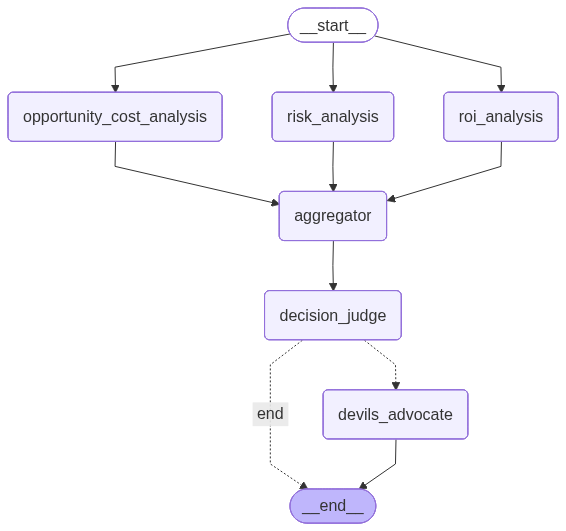

In [34]:
display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)

In [69]:
def target(inputs: dict) -> dict:
    result = workflow.invoke({
        "decision": inputs["decision"]
    })

    return {
        "verdict": result["verdict"],
        "confidence": result["confidence"],
        "reasoning": result["reasoning"]
    }

In [70]:
from langsmith import Client

client = Client()

experiment_results = client.evaluate(
    target,
    data="decision-council-dataset",
    experiment_prefix="decision-council-v1"
)

View the evaluation results for experiment: 'decision-council-v1-7d1b1e08' at:
https://smith.langchain.com/o/d1fc1580-c163-4a39-93b8-37dcea864e70/datasets/7353b8e9-e988-4032-9f2f-d879839f6550/compare?selectedSessions=83380069-ca36-4cf5-b6c6-87087ea740ee




0it [00:00, ?it/s]